<a href="https://colab.research.google.com/github/LGib1/D195Capstone/blob/main/D195FraudClusters.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Import needed packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [2]:
transactions = pd.read_csv('/content/drive/MyDrive/transactions.csv')

In [3]:
transactions.head(1)

,transaction_id,account_id,timestamp,hour_of_day,day_of_week,is_weekend,amount,merchant_category,mcc_code,merchant_country,...,ip_risk_score,is_foreign_txn,time_since_last_s,velocity_1h,amount_vs_avg_ratio,account_age_days,has_2fa,credit_limit,is_fraud,fraud_pattern
0,TXN000000001,ACC0016173,2/21/2023 8:02,8,1,0,168.42,travel,4511,CA,...,53.2,1,21,3,2.6423,3256,1,3958.46,0,NaN


In [4]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 23 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   transaction_id       1000000 non-null  object 
 1   account_id           1000000 non-null  object 
 2   timestamp            1000000 non-null  object 
 3   hour_of_day          1000000 non-null  int64  
 4   day_of_week          1000000 non-null  int64  
 5   is_weekend           1000000 non-null  int64  
 6   amount               1000000 non-null  float64
 7   merchant_category    1000000 non-null  object 
 8   mcc_code             1000000 non-null  int64  
 9   merchant_country     1000000 non-null  object 
 10  card_present         1000000 non-null  int64  
 11  device_type          1000000 non-null  object 
 12  device_known         1000000 non-null  int64  
 13  ip_risk_score        1000000 non-null  float64
 14  is_foreign_txn       1000000 non-null  int64  
 15 

In [5]:
#View relationship between columns
display(transactions[['merchant_category', 'mcc_code']].drop_duplicates())

,merchant_category,mcc_code
0,travel,4511
1,online_retail,5999
2,pharmacy,5912
3,grocery,5411
5,clothing,5600
6,atm,6011
9,restaurant,5812
10,gas_station,5541
11,electronics,5734
17,hotel,7011


In [6]:
transactions.describe()

,hour_of_day,day_of_week,is_weekend,amount,mcc_code,card_present,device_known,ip_risk_score,is_foreign_txn,time_since_last_s,velocity_1h,amount_vs_avg_ratio,account_age_days,has_2fa,credit_limit,is_fraud
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,11.494197,3.003311,0.287152,183.738264,5703.713286,0.350654,0.892337,21.605828,0.294417,180.112610,1.050421,3.298512,1833.588908,0.647567,6706.938185,0.017143
std,6.920962,2.002666,0.452433,316.693903,548.917957,0.477175,0.309954,16.269652,0.455780,180.148636,1.095055,7.157055,1046.489932,0.477728,6174.164106,0.129804
min,0.000000,0.000000,0.000000,1.830000,4511.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.011800,30.000000,0.000000,500.000000,0.000000
25%,5.000000,1.000000,0.000000,43.480000,5411.000000,0.000000,1.000000,8.500000,0.000000,52.000000,0.000000,0.597100,926.000000,0.000000,2833.750000,0.000000
50%,11.000000,3.000000,0.000000,81.140000,5734.000000,0.000000,1.000000,18.700000,0.000000,125.000000,1.000000,1.285300,1832.000000,1.000000,4880.100000,0.000000
75%,17.000000,5.000000,1.000000,189.760000,5999.000000,1.000000,1.000000,30.700000,1.000000,250.000000,2.000000,3.155500,2738.000000,1.000000,8384.040000,0.000000
max,23.000000,6.000000,1.000000,25000.000000,7995.000000,1.000000,1.000000,100.000000,1.000000,2733.000000,15.000000,945.537100,3649.000000,1.000000,50000.000000,1.000000


In [7]:
#fraud_pattern is not used in analysis
transactions['fraud_pattern'].value_counts()

,count
fraud_pattern,
card_not_present,5982
account_takeover,3432
card_present_stolen,3120
friendly_fraud,1726
atm_fraud,1216
money_laundering,1011
identity_theft,656


In [8]:
transactions.isna().sum()

,0
transaction_id,0
account_id,0
timestamp,0
hour_of_day,0
day_of_week,0
is_weekend,0
amount,0
merchant_category,0
mcc_code,0
merchant_country,0


In [9]:
transactions['is_fraud'].value_counts()

,count
is_fraud,
0,982857
1,17143


In [10]:
#what percent is fraud
Percent_fraud = transactions['is_fraud'].value_counts()[1] / transactions['is_fraud'].value_counts()[0]
Percent_fraud*100

np.float64(1.744200834912912)

In [11]:
#hour of day is derived from timestamp
#Note the hour is not rounded, exp 9:59 is expressed as 9 versus rounding to 10
transactions[['timestamp', 'hour_of_day']].value_counts().index

MultiIndex([( '10/1/2024 8:13',  8),
            ( '6/16/2024 4:28',  4),
            (  '6/5/2023 7:50',  7),
            ('1/30/2022 17:44', 17),
            ( '9/7/2023 22:17', 22),
            ('1/30/2024 17:10', 17),
            ( '1/19/2023 1:29',  1),
            ('4/12/2024 18:30', 18),
            ('9/27/2024 13:52', 13),
            ('4/13/2022 11:41', 11),
            ...
            ( '12/2/2023 8:19',  8),
            ( '12/2/2023 8:21',  8),
            (  '1/1/2022 0:03',  0),
            (  '1/1/2022 0:05',  0),
            (  '1/1/2022 0:07',  0),
            (  '1/1/2022 0:09',  0),
            (  '1/1/2022 0:10',  0),
            (  '1/1/2022 0:19',  0),
            (  '1/1/2022 0:20',  0),
            (  '1/1/2022 0:25',  0)],
           names=['timestamp', 'hour_of_day'], length=740865)

In [12]:
transactions['hour_of_day'].unique()

array([ 8, 23, 17,  5, 12,  2, 18,  3,  9, 15, 20,  0, 21, 10,  4,  7, 13,
       14, 16, 22, 19,  1, 11,  6])

In [13]:
transactions['day_of_week'].unique()


array([1, 6, 4, 2, 3, 5, 0])

In [14]:
#Determine correlation structure
#10/01/2024 = Tuesday = 1; 06/16/2024 = Sunday = 6; 06/05/2023 = Monday = 0
#Therefore, Monday:0, Tuesday:1, Wednesday:2, Thursday:3, Friday:4, Saturday:5, Sunday: 6
transactions[['timestamp', 'day_of_week']].sort_values(by='timestamp', ascending=False).value_counts().head()



,,count
timestamp,day_of_week,
10/1/2024 8:13,1,8
6/16/2024 4:28,6,8
6/5/2023 7:50,0,7
1/30/2022 17:44,6,7
9/7/2023 22:17,3,7


In [15]:
transactions.dtypes

,0
transaction_id,object
account_id,object
timestamp,object
hour_of_day,int64
day_of_week,int64
is_weekend,int64
amount,float64
merchant_category,object
mcc_code,int64
merchant_country,object


In [16]:
transactions['merchant_category'].value_counts()

,count
merchant_category,
grocery,180167
online_retail,150118
restaurant,120406
gas_station,80030
atm,79595
clothing,70072
pharmacy,60295
electronics,60229
hotel,49490


In [17]:
#create a copy of the data, retain the original
df = transactions.copy()

In [18]:
#re-encode merchant_category to numeric values
#map the merchant_category values
mapping = {
    "travel": 1,
    "online_retail": 2,
    "pharmacy": 3,
    "grocery": 4,
    "clothing": 5,
    "atm": 6,
    "restaurant": 7,
    "gas_station": 8,
    "electronics": 9,
    "hotel": 10,
    "utilities": 11,
    "money_transfer": 12,
    "crypto": 13,
    "gambling": 14
}

df['merchant_category'] = df['merchant_category'].map(mapping)
df.head(2)

,transaction_id,account_id,timestamp,hour_of_day,day_of_week,is_weekend,amount,merchant_category,mcc_code,merchant_country,...,ip_risk_score,is_foreign_txn,time_since_last_s,velocity_1h,amount_vs_avg_ratio,account_age_days,has_2fa,credit_limit,is_fraud,fraud_pattern
0,TXN000000001,ACC0016173,2/21/2023 8:02,8,1,0,168.42,1,4511,CA,...,53.2,1,21,3,2.6423,3256,1,3958.46,0,NaN
1,TXN000000002,ACC0011196,5/12/2024 23:13,23,6,1,85.78,2,5999,AU,...,25.3,1,234,1,0.7279,1527,1,3553.35,0,NaN


In [19]:
df['merchant_category'].dtype

dtype('int64')

In [20]:
#Identify and scale appropriate features. Only use features needed.
numeric_features = [
    "amount",
    "hour_of_day",
    "day_of_week",
    "ip_risk_score",
    "time_since_last_s",
    "velocity_1h"
]

# Categorical numeric label (DO NOT SCALE)
categorical_features = ["merchant_category"]

# Binary features
binary_features = ["card_present", "device_known", "is_foreign_txn"]

# Scale only true numeric continuous features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[numeric_features])
X_scaled_df = pd.DataFrame(X_scaled, columns=numeric_features)

# Combine scaled numeric + unscaled categorical + binary
X_preprocessed = pd.concat([
    X_scaled_df.reset_index(drop=True),
    df[categorical_features].reset_index(drop=True),
    df[binary_features].reset_index(drop=True)
], axis=1)

X_preprocessed.head()


,amount,hour_of_day,day_of_week,ip_risk_score,time_since_last_s,velocity_1h,merchant_category,card_present,device_known,is_foreign_txn
0,-0.048369,-0.504872,-1.000323,1.941909,-0.883230,1.780349,1,0,1,1
1,-0.309315,1.662458,1.496351,0.227059,0.299128,-0.046044,2,0,1,1
2,-0.516550,1.662458,0.497681,-0.018797,-0.527968,-0.046044,3,0,1,1
3,-0.382857,1.662458,-0.500988,-0.485925,-0.455805,-0.959241,4,0,1,0
4,-0.353838,0.795526,-0.001653,-0.731782,3.002452,0.867152,2,0,1,0


In [21]:
#extract target variable, is_fraud
y = df['is_fraud'].reset_index(drop=True)

In [22]:
#implement PCA
pca = PCA()
X_pca = pca.fit_transform(X_preprocessed)

In [23]:
pca_df=pd.DataFrame(X_pca, columns=[f"PC{i+1}" for i in range(X_pca.shape[1])])
pca_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,-4.770242,2.733551,-1.262189,-0.511451,-0.238074,0.180619,-0.534816,-0.335066,0.254994,0.173830
1,-3.812544,0.133378,0.798995,1.866691,1.028593,0.246710,0.042062,-0.341691,0.634012,0.097948
2,-2.838790,-0.159557,-0.427317,1.453495,0.991367,0.175929,-0.216355,-0.342603,0.688857,0.090417
3,-1.836266,-1.191578,-0.915580,0.635368,1.287348,0.235609,0.277465,-0.358998,-0.182505,0.078669
4,-3.819173,-0.063242,2.271762,-0.846375,1.897636,-1.168586,-0.390340,-0.349870,-0.104068,0.114130


In [24]:
pca_df['is_fraud'] = y.values
pca_df['is_fraud'].value_counts()


,count
is_fraud,
0,982857
1,17143


In [25]:
var_exp = pca.explained_variance_ratio_
var_exp

array([0.61987369, 0.06850258, 0.05906872, 0.05904245, 0.05891454,
       0.05512063, 0.05100066, 0.01344126, 0.00941361, 0.00562187])

In [26]:
cum_var_exp = np.cumsum(var_exp)
cum_var_exp

array([0.61987369, 0.68837626, 0.74744498, 0.80648743, 0.86540197,
       0.9205226 , 0.97152326, 0.98496452, 0.99437813, 1.        ])

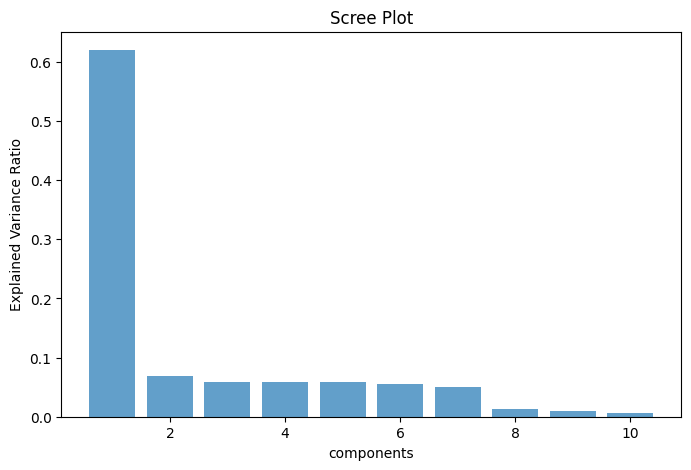

In [27]:
plt.figure(figsize=(8,5))
plt.bar(range(1, len(var_exp) +1), var_exp, alpha=0.7, align='center')
plt.xlabel("components")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.show()


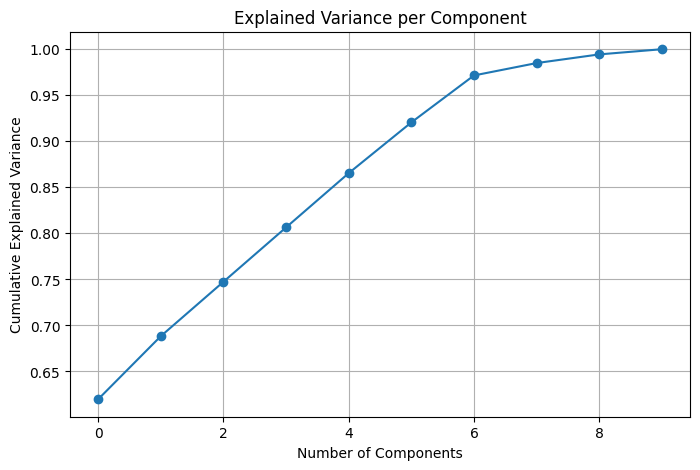

In [28]:
plt.figure(figsize=(8,5))
plt.plot(cum_var_exp, marker='o')
plt.title("Explained Variance per Component")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True)
plt.show;


In [29]:
#determine number of components to use
n_components_95 = np.argmax(cum_var_exp >= 0.95) + 1
n_components_95

np.int64(7)

In [30]:
pca = PCA(n_components=7, random_state=42)
X_pca = pca.fit_transform(X_preprocessed)
#pca_df
pca_df = pd.DataFrame(X_pca, columns=[f"PC{i}" for i in range(1,8)])
pca_df['is_fraud'] = y.values
pca_df.head()


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,is_fraud
0,-4.770242,2.733551,-1.262189,-0.511451,-0.238074,0.180619,-0.534816,0
1,-3.812544,0.133378,0.798995,1.866691,1.028593,0.246710,0.042062,0
2,-2.838790,-0.159557,-0.427317,1.453495,0.991367,0.175929,-0.216355,0
3,-1.836266,-1.191578,-0.915580,0.635368,1.287348,0.235609,0.277465,0
4,-3.819173,-0.063242,2.271762,-0.846375,1.897636,-1.168586,-0.390340,0


In [31]:
#KMeans clustering, tuning to 7 components
kmeans = KMeans(n_clusters=7, random_state=42)
clusters = kmeans.fit_predict(X_preprocessed)
pca_df['cluster'] = clusters
df['cluster']=clusters

In [32]:
#obtain a silhouette score
##This method was taking too long due to the dataset size, will attempt to optimize

#labels = kmeans.labels_
#sil_score = silhouette_score(X_pca, clusters)
#print(f'Silhouette Score: {sil_score}')

In [33]:
#optimized silhouette score

from sklearn.cluster import MiniBatchKMeans

# store results
silhouette_results = []

# sample once for consistency
sample_idx = np.random.choice(len(X_pca), size=30000, replace=False)
X_sample = X_pca[sample_idx]


for k in range(2, 13):
    print(f"Evaluating k = {k}...")

    # fast clustering for large datasets
    kmeans_minibatch = MiniBatchKMeans(
        n_clusters=k,
        batch_size=10000,
        random_state=42
    )

    # fit on full dataset
    clusters_full = kmeans_minibatch.fit_predict(X_pca)

    # evaluate on sample
    clusters_sample = clusters_full[sample_idx]
    sil_score = silhouette_score(X_sample, clusters_sample)

    silhouette_results.append((k, sil_score))
    print(f"Silhouette Score for k={k}: {sil_score:.4f}")

# show results
silhouette_results



Evaluating k = 2...
Silhouette Score for k=2: 0.3794
Evaluating k = 3...
Silhouette Score for k=3: 0.2708
Evaluating k = 4...
Silhouette Score for k=4: 0.1850
Evaluating k = 5...
Silhouette Score for k=5: 0.1462
Evaluating k = 6...
Silhouette Score for k=6: 0.1415
Evaluating k = 7...
Silhouette Score for k=7: 0.1379
Evaluating k = 8...
Silhouette Score for k=8: 0.1351
Evaluating k = 9...
Silhouette Score for k=9: 0.1282
Evaluating k = 10...
Silhouette Score for k=10: 0.1217
Evaluating k = 11...
Silhouette Score for k=11: 0.1211
Evaluating k = 12...
Silhouette Score for k=12: 0.1176


[(2, np.float64(0.37939520197497517)),
 (3, np.float64(0.2707582753763431)),
 (4, np.float64(0.1850484793359854)),
 (5, np.float64(0.14616297665489286)),
 (6, np.float64(0.14148945562911994)),
 (7, np.float64(0.13785262196137926)),
 (8, np.float64(0.13510105774359046)),
 (9, np.float64(0.12817904864404986)),
 (10, np.float64(0.12173105644371283)),
 (11, np.float64(0.12114105216774897)),
 (12, np.float64(0.11757282152794729))]

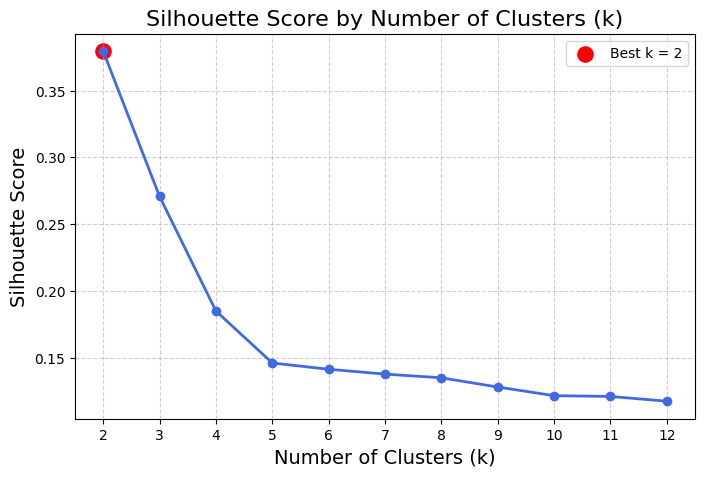

In [34]:
# unpack results
ks = [k for k, score in silhouette_results]
scores = [score for k, score in silhouette_results]

plt.figure(figsize=(8, 5))
plt.plot(ks, scores, marker='o', linewidth=2, color='royalblue')
plt.title("Silhouette Score by Number of Clusters (k)", fontsize=16)
plt.xlabel("Number of Clusters (k)", fontsize=14)
plt.ylabel("Silhouette Score", fontsize=14)
plt.xticks(ks)
plt.grid(True, linestyle='--', alpha=0.6)

# highlight the best k
best_k = ks[scores.index(max(scores))]
best_score = max(scores)
plt.scatter(best_k, best_score, color='red', s=120, label=f"Best k = {best_k}")
plt.legend()

plt.show()

Although k=2 appears to have the best silhouette score, it is misleading because there are only 2 clusters, essentially normal versus everything else. This would be a poor choice because it is too  broad.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


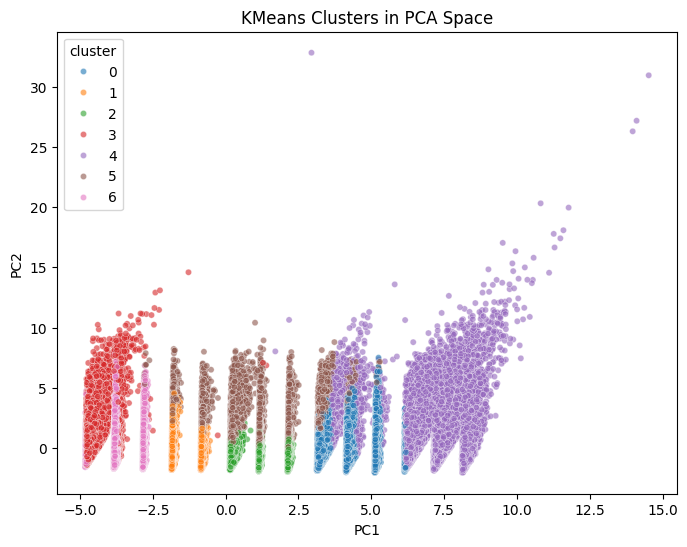

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pca_df,
    x="PC1", y="PC2",
    hue="cluster",
    palette="tab10",
    alpha=0.6,
    s=20
)
plt.title("KMeans Clusters in PCA Space")
plt.show()


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


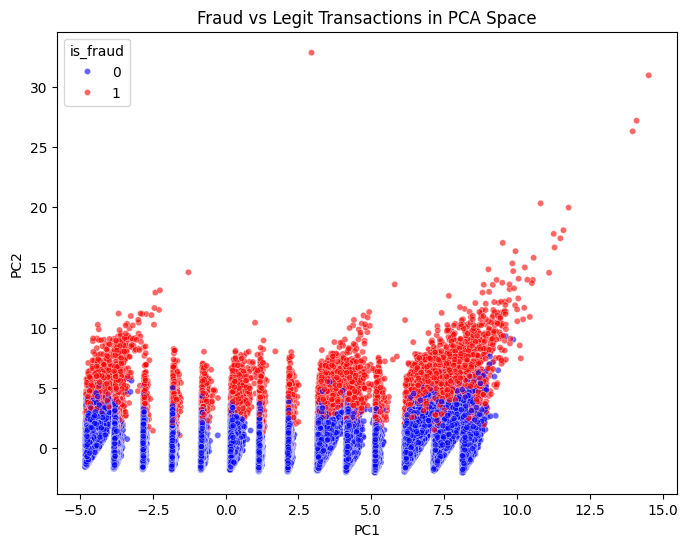

In [36]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pca_df,
    x="PC1", y="PC2",
    hue="is_fraud",
    palette={0: "blue", 1: "red"},
    alpha=0.6,
    s=20
)
plt.title("Fraud vs Legit Transactions in PCA Space")
plt.show()


In [37]:
cluster_summary = (
    df.groupby("cluster")["is_fraud"]
    .agg(["count", "sum"])
    .rename(columns={"sum": "fraud_count"})
)

cluster_summary["fraud_rate"] = (
    cluster_summary["fraud_count"] / cluster_summary["count"]
)

cluster_summary



,count,fraud_count,fraud_rate
cluster,,,
0,148422,1368,0.009217
1,243283,1641,0.006745
2,204895,22,0.000107
3,46964,1760,0.037476
4,58697,3133,0.053376
5,84936,6755,0.079530
6,212803,2464,0.011579


/tmp/ipykernel_433/1170262070.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


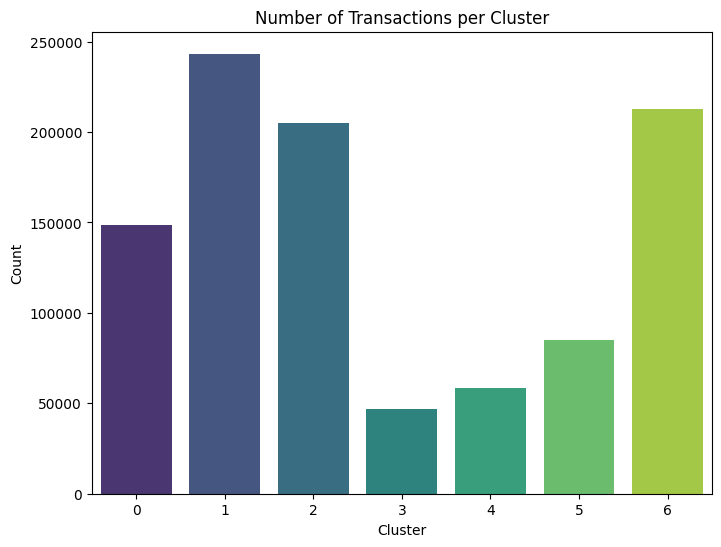

In [38]:
#cluster size
plt.figure(figsize=(8,6))
sns.barplot(
    x=cluster_summary.index,
    y=cluster_summary["count"],
    palette="viridis"
)
plt.title("Number of Transactions per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.show()


/tmp/ipykernel_433/2411162787.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


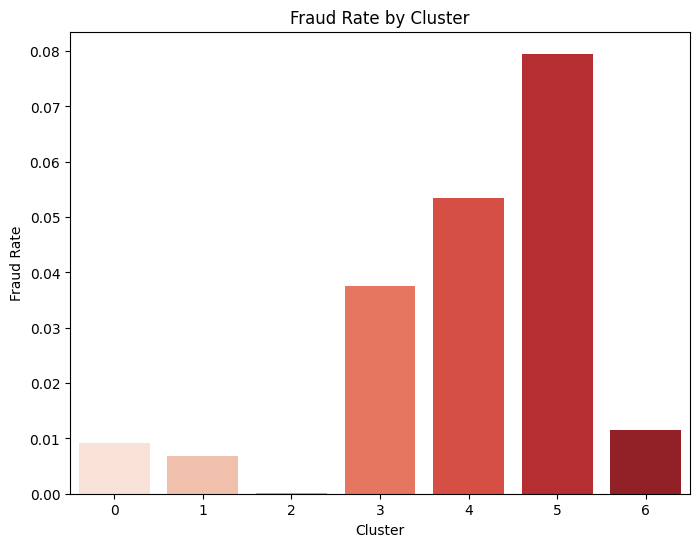

In [39]:
#fraud rate per cluster
plt.figure(figsize=(8,6))
sns.barplot(
    x=cluster_summary.index,
    y=cluster_summary["fraud_rate"],
    palette="Reds"
)
plt.title("Fraud Rate by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Fraud Rate")
plt.show()


In [40]:
cluster_number = 5
cluster_data = df[df["cluster"] == cluster_number]
cluster_data.head()

,transaction_id,account_id,timestamp,hour_of_day,day_of_week,is_weekend,amount,merchant_category,mcc_code,merchant_country,...,is_foreign_txn,time_since_last_s,velocity_1h,amount_vs_avg_ratio,account_age_days,has_2fa,credit_limit,is_fraud,fraud_pattern,cluster
8,TXN000000009,ACC0019600,5/24/2022 2:18,2,1,0,47.24,5,5600,US,...,0,123,2,0.2998,1491,1,4359.96,0,NaN,5
20,TXN000000021,ACC0011810,12/2/2022 0:13,0,4,0,17.36,8,5541,US,...,0,224,2,0.5553,1712,1,1472.13,0,NaN,5
23,TXN000000024,ACC0045692,5/25/2024 4:00,4,5,1,41.26,7,5812,US,...,0,72,0,0.2867,2487,1,2414.48,0,NaN,5
53,TXN000000054,ACC0027163,6/30/2024 15:24,15,6,1,245.51,6,6011,MX,...,1,137,1,3.2717,1240,0,695.24,0,NaN,5
60,TXN000000061,ACC0046781,6/11/2023 18:33,18,6,1,92.12,8,5541,DE,...,1,242,1,1.1599,3322,1,4064.22,0,NaN,5


In [41]:
cluster_number = 5
cluster_data = pca_df[pca_df["cluster"] == cluster_number]
cluster_data.head()


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,is_fraud,cluster
8,-0.830749,1.784383,-0.633732,-1.251380,-0.773296,0.828719,-0.745581,0,5
20,2.146602,1.585629,0.730228,-0.538010,-1.306545,0.862802,-1.077736,0,5
23,1.150727,0.165663,0.269419,0.433285,-1.429712,1.675349,-0.048291,0,5
53,0.226635,2.062694,0.512861,1.575321,0.055825,2.021569,0.104901,0,5
60,2.163771,0.585900,0.946801,1.481131,0.509698,1.030018,-0.451819,0,5


In [42]:
#convert centroid back into the original features for interpretation
all_features = numeric_features + categorical_features + binary_features

# Extract centroid in preprocessed space
cluster_centroid_preprocessed = kmeans.cluster_centers_[cluster_number]

# Split into numeric + categorical + binary
n_numeric = len(numeric_features)
n_categorical = len(categorical_features)

centroid_numeric_scaled = cluster_centroid_preprocessed[:n_numeric]
centroid_categorical = cluster_centroid_preprocessed[n_numeric:n_numeric + n_categorical]
centroid_binary = cluster_centroid_preprocessed[n_numeric + n_categorical:]

# Inverse transform numeric only
centroid_numeric_original = scaler.inverse_transform(
    centroid_numeric_scaled.reshape(1, -1)
)[0]

# Rebuild centroid vector in correct order
cluster_centroid_original = np.concatenate(
    [centroid_numeric_original, centroid_categorical, centroid_binary]
)

# Build DataFrame
centroid_df = pd.DataFrame(
    [cluster_centroid_original],
    columns=all_features
)

centroid_df

,amount,hour_of_day,day_of_week,ip_risk_score,time_since_last_s,velocity_1h,merchant_category,card_present,device_known,is_foreign_txn
0,122.917059,11.095829,2.985313,44.271839,179.437393,1.629977,6.844438,0.346081,0.861284,0.583359


In [43]:
centroid_df.T.sort_values(by=0, ascending=False).head(15)

,0
time_since_last_s,179.437393
amount,122.917059
ip_risk_score,44.271839
hour_of_day,11.095829
merchant_category,6.844438
day_of_week,2.985313
velocity_1h,1.629977
device_known,0.861284
is_foreign_txn,0.583359
card_present,0.346081


In [44]:
centroids_original = []

for c in kmeans.cluster_centers_:

    # Split centroid into numeric, categorical, binary
    n_numeric = len(numeric_features)
    n_categorical = len(categorical_features)

    numeric_scaled = c[:n_numeric]
    categorical_vals = c[n_numeric:n_numeric + n_categorical]
    binary_vals = c[n_numeric + n_categorical:]

    # Inverse-transform numeric only
    numeric_original = scaler.inverse_transform(
        numeric_scaled.reshape(1, -1)
    )[0]

    # Rebuild centroid vector in correct order
    centroid_full = np.concatenate(
        [numeric_original, categorical_vals, binary_vals]
    )

    centroids_original.append(centroid_full)

# Build DataFrame
centroid_df = pd.DataFrame(
    centroids_original,
    columns=all_features
)

centroid_df

,amount,hour_of_day,day_of_week,ip_risk_score,time_since_last_s,velocity_1h,merchant_category,card_present,device_known,is_foreign_txn
0,267.035756,11.494380,3.009643,20.634369,180.081334,1.008430,9.915270,0.351173,0.895735,0.282278
1,64.916208,11.509987,3.003110,20.401548,180.684664,1.000965,4.266057,0.350454,0.896233,0.282967
2,97.831813,11.615622,3.004489,14.014524,180.169835,0.863454,7.021259,0.351211,0.901081,0.193783
3,593.006369,11.481336,2.995635,22.570688,179.254669,1.146860,1.021826,0.349765,0.885420,0.299832
4,874.591237,11.495119,3.024977,22.854148,178.314183,1.168038,12.641520,0.348991,0.876991,0.300077
5,122.917059,11.095829,2.985313,44.271839,179.437393,1.629977,6.844438,0.346081,0.861284,0.583359
6,87.603571,11.521496,3.000921,21.318268,180.380959,1.030042,2.267226,0.352473,0.895308,0.294175


Converting to original columns labels identifies avg columns

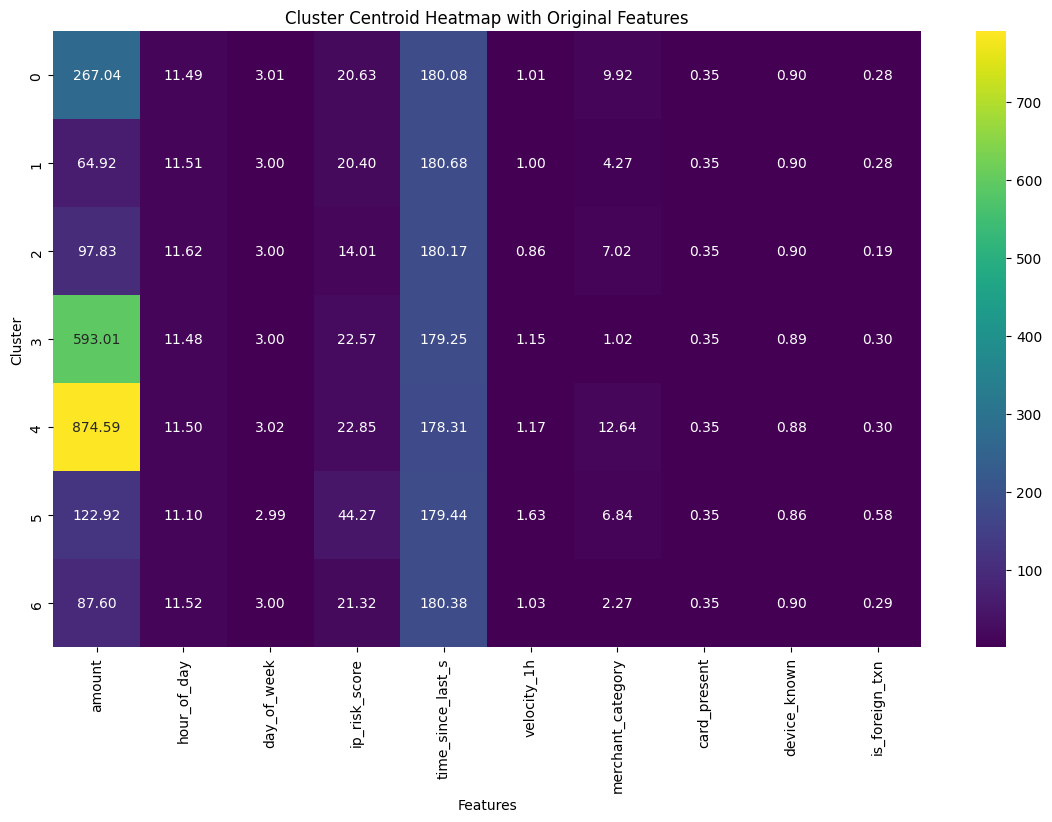

In [45]:
#convert to graphical visualization
plt.figure(figsize=(14,8))
sns.heatmap(
    centroid_df,
    annot=True,
    cmap="viridis",
    fmt=".2f",
    vmin = centroid_df.quantile(0.05).min(),
    vmax = centroid_df.quantile(0.95).max()
)

plt.title("Cluster Centroid Heatmap with Original Features")
plt.xlabel("Features")
plt.ylabel("Cluster")
plt.show()

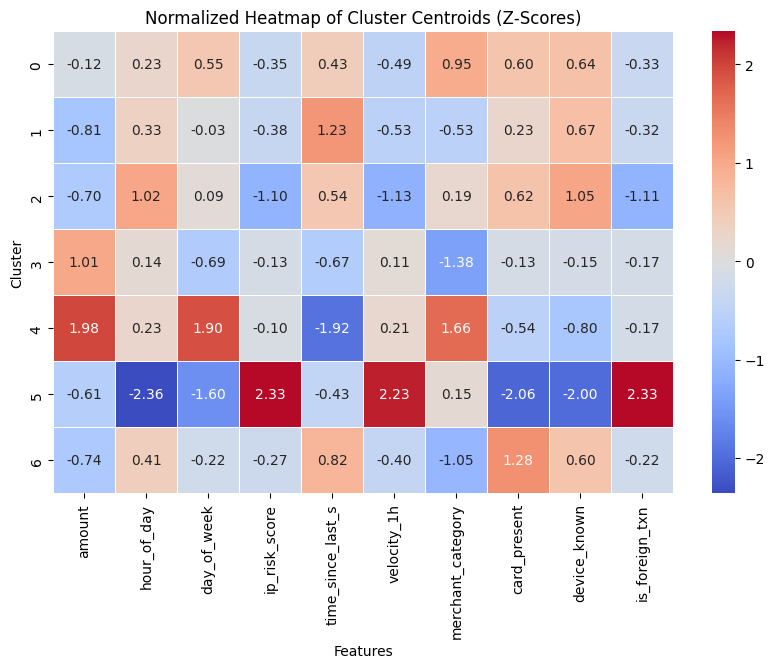

In [46]:
#heatmap with relative differences between clusters, uses z-scores to compare clusters

# Normalize centroid_df across features (columns)
# 0= average, > 0 = above average, <0= below average
scaler = StandardScaler()
centroids_normalized = scaler.fit_transform(centroid_df)

centroids_normalized_df = pd.DataFrame(
    centroids_normalized,
    columns=centroid_df.columns,
    index=centroid_df.index
)

plt.figure(figsize=(10, 6))
sns.heatmap(
    centroids_normalized_df,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Normalized Heatmap of Cluster Centroids (Z‑Scores)")
plt.xlabel("Features")
plt.ylabel("Cluster")
plt.show()


In [47]:
#review amount in high-risk clusters
df[df["cluster"].isin([3, 4, 5])].groupby("cluster")["amount"].describe()



,count,mean,std,min,25%,50%,75%,max
cluster,,,,,,,,
3,46964.0,593.000102,435.595636,69.29,334.1575,479.765,709.5525,11443.99
4,58697.0,874.519163,772.968518,28.10,434.4400,664.960,1050.3900,25000.00
5,84936.0,123.119464,157.400929,1.94,37.8000,69.085,149.2600,3631.98


In [48]:
#review amount in low-risk clusters
df[df["cluster"].isin([0, 1, 2, 6])].groupby("cluster")["amount"].describe()



,count,mean,std,min,25%,50%,75%,max
cluster,,,,,,,,
0,148422.0,267.063829,207.181911,7.10,121.21,210.785,349.5375,1639.25
1,243283.0,64.902102,48.326038,2.99,33.65,51.890,80.9600,1027.97
2,204895.0,97.757041,107.143649,3.23,34.28,58.810,117.9800,2309.30
6,212803.0,87.602271,60.693801,1.83,44.50,71.630,113.6000,626.99


In [49]:
#review IP risk score  in clusters
df.groupby("cluster")["ip_risk_score"].describe()




,count,mean,std,min,25%,50%,75%,max
cluster,,,,,,,,
0,148422.0,20.640879,15.170540,0.0,8.2,18.2,29.6,100.0
1,243283.0,20.384443,14.796875,0.0,8.2,18.2,29.3,84.3
2,204895.0,14.048853,9.148593,0.0,5.9,13.9,20.8,40.2
3,46964.0,22.571414,17.015559,0.0,8.9,19.4,31.9,100.0
4,58697.0,22.852699,17.318243,0.0,9.0,19.4,32.6,100.0
5,84936.0,44.346650,14.636406,0.5,34.0,41.9,52.9,100.0
6,212803.0,21.317759,15.996323,0.0,8.4,18.6,30.3,100.0


In [50]:
#review time since last transaction  in clusters
df.groupby("cluster")["time_since_last_s"].describe()




,count,mean,std,min,25%,50%,75%,max
cluster,,,,,,,,
0,148422.0,180.090991,180.670029,1.0,52.0,125.0,249.0,2733.0
1,243283.0,180.684100,180.792941,1.0,52.0,125.0,251.0,2230.0
2,204895.0,180.192274,180.531269,1.0,52.0,125.0,249.0,2438.0
3,46964.0,179.256068,178.717280,1.0,52.0,124.0,249.0,1763.0
4,58697.0,178.305416,178.763093,1.0,52.0,123.0,247.0,2039.0
5,84936.0,179.370314,179.051967,1.0,52.0,124.0,248.0,2070.0
6,212803.0,180.381418,179.806849,1.0,52.0,125.0,250.0,2244.0


In [51]:
#review velocity  in clusters
df.groupby("cluster")["velocity_1h"].describe()




,count,mean,std,min,25%,50%,75%,max
cluster,,,,,,,,
0,148422.0,1.008442,1.029354,0.0,0.0,1.0,2.0,12.0
1,243283.0,1.000201,1.010694,0.0,0.0,1.0,2.0,9.0
2,204895.0,0.863530,0.904382,0.0,0.0,1.0,1.0,6.0
3,46964.0,1.146964,1.213858,0.0,0.0,1.0,2.0,14.0
4,58697.0,1.167981,1.275067,0.0,0.0,1.0,2.0,12.0
5,84936.0,1.635008,1.464840,0.0,1.0,1.0,2.0,15.0
6,212803.0,1.030000,1.063121,0.0,0.0,1.0,2.0,11.0


In [52]:
#review card present in high-risk, deep blue
df[df["cluster"].isin([3, 4, 5])].groupby("cluster")["card_present"].value_counts(normalize=True) * 100




cluster  card_present
3        0               65.024274
         1               34.975726
4        0               65.097024
         1               34.902976
5        0               65.396298
         1               34.603702
Name: proportion, dtype: float64

In [53]:
#review card present in low-risk
df[df["cluster"].isin([0, 1, 2, 6])].groupby("cluster")["card_present"].value_counts(normalize=True) * 100




cluster  card_present
0        0               64.887281
         1               35.112719
1        0               64.951928
         1               35.048072
2        0               64.879084
         1               35.120916
6        0               64.752377
         1               35.247623
Name: proportion, dtype: float64

In [54]:
high_risk = df[df["cluster"].isin([3, 4, 5])]
low_risk = df[df["cluster"].isin([0, 1, 2, 6])]

# Percentage distribution for each group
high_pct = (
    high_risk["card_present"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("high_risk_pct")
)

low_pct = (
    low_risk["card_present"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("low_risk_pct")
)

# Combine into one DataFrame
pct_df = pd.concat([high_pct, low_pct], axis=1).fillna(0).sort_index()
pct_df


,high_risk_pct,low_risk_pct
card_present,,
0,65.212464,64.869169
1,34.787536,35.130831


In [55]:
#review in clusters
df.groupby("cluster")["device_known"].value_counts(normalize=True) * 100




cluster  device_known
0        1               89.571627
         0               10.428373
1        1               89.628951
         0               10.371049
2        1               90.105664
         0                9.894336
3        1               88.540158
         0               11.459842
4        1               87.701245
         0               12.298755
5        1               86.104832
         0               13.895168
6        1               89.531163
         0               10.468837
Name: proportion, dtype: float64

In [56]:
high_risk = df[df["cluster"].isin([3, 4, 5])]
low_risk = df[df["cluster"].isin([0, 1, 2, 6])]

# Percentage distribution for each group
high_pct = (
    high_risk["device_known"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("high_risk_pct")
)

low_pct = (
    low_risk["device_known"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("low_risk_pct")
)

# Combine into one DataFrame
pct_df = pd.concat([high_pct, low_pct], axis=1).fillna(0).sort_index()
pct_df


,high_risk_pct,low_risk_pct
device_known,,
0,12.803454,10.286594
1,87.196546,89.713406


In [57]:
#review merchant_categories
#1=Travel, 2=online_retail, 3=pharmacy, 4=grocery, 5=clothing, 6=atm,
#7=restaurant, 8=gas_station, 9=electronics, 10=hotel, 11= utilities,
#12=money_transfer, 13=crypto, 14=gambling
df[df["cluster"].isin([3, 4, 5])].groupby("cluster")["merchant_category"].value_counts(ascending=True)

cluster  merchant_category
3        5                        1
         6                        3
         3                        4
         2                      999
         1                    45957
4        1                        1
         6                        2
         11                      62
         10                     267
         9                      512
         14                    9920
         13                   19976
         12                   27957
5        11                      10
         3                       16
         10                     144
         4                     1572
         9                     2680
         5                     5383
         8                    19485
         6                    23546
         7                    32100
Name: count, dtype: int64

In [58]:
#Review categories in  high risk clusters as a percentage
#1=Travel, 2=online_retail, 3=pharmacy, 4=grocery, 5=clothing,
#6=atm, 7=restaurant, 8=gas_station, 9=electronics, 10=hotel,
#11= utilities, 12=money_transfer, 13=crypto, 14=gambling
high_risk = df[df["cluster"].isin([3, 4, 5])]

(
    high_risk.groupby("cluster")["merchant_category"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)


cluster  merchant_category
3        1                    97.86
         2                     2.13
         3                     0.01
         6                     0.01
         5                     0.00
4        12                   47.63
         13                   34.03
         14                   16.90
         9                     0.87
         10                    0.45
         11                    0.11
         6                     0.00
         1                     0.00
5        7                    37.79
         6                    27.72
         8                    22.94
         5                     6.34
         9                     3.16
         4                     1.85
         10                    0.17
         3                     0.02
         11                    0.01
Name: proportion, dtype: float64

In [59]:
#review merchant_categories
#1=Travel, 2=online_retail, 3=pharmacy, 4=grocery, 5=clothing, 6=atm,
#7=restaurant, 8=gas_station, 9=electronics, 10=hotel, 11= utilities,
#12=money_transfer, 13=crypto, 14=gambling
df[df["cluster"].isin([0, 1, 2, 6])].groupby("cluster")["merchant_category"].value_counts(ascending=True)





cluster  merchant_category
0        12                     2122
         11                    40184
         10                    49079
         9                     57037
1        5                     64688
         4                    178595
2        6                     56044
         8                     60545
         7                     88306
6        1                      3409
         3                     60275
         2                    149119
Name: count, dtype: int64

In [60]:
#Review categories in  low risk clusters as a percentage
#1=Travel, 2=online_retail, 3=pharmacy, 4=grocery, 5=clothing,
#6=atm, 7=restaurant, 8=gas_station, 9=electronics, 10=hotel,
#11= utilities, 12=money_transfer, 13=crypto, 14=gambling
low_risk = df[df["cluster"].isin([0, 1, 2, 6])]

(
    low_risk.groupby("cluster")["merchant_category"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)


cluster  merchant_category
0        9                    38.43
         10                   33.07
         11                   27.07
         12                    1.43
1        4                    73.41
         5                    26.59
2        7                    43.10
         8                    29.55
         6                    27.35
6        2                    70.07
         3                    28.32
         1                     1.60
Name: proportion, dtype: float64

In [61]:
#compare merchant categories between high risk and low risk clusters using normalization
# Define groups
high_risk = df[df["cluster"].isin([3, 4, 5])]
low_risk = df[df["cluster"].isin([0, 1, 2, 6])]

# Percentage distribution for each group
high_pct = (
    high_risk["merchant_category"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("high_risk_pct")
)

low_pct = (
    low_risk["merchant_category"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("low_risk_pct")
)



# Combine into one DataFrame
pct_df = pd.concat([high_pct, low_pct], axis=1).fillna(0).sort_index()

#calculate difference
pct_df["pct_change"] = ((pct_df["high_risk_pct"] - pct_df["low_risk_pct"]) /
                        pct_df["low_risk_pct"]) * 100

pct_df

,high_risk_pct,low_risk_pct,pct_change
merchant_category,,,
1,24.112657,0.421175,5625.097257
2,0.524143,18.423332,-97.155007
3,0.010493,7.446847,-99.859090
4,0.824777,22.065028,-96.262063
5,2.824808,7.992063,-64.654830
6,12.356438,6.924116,78.455105
7,16.841818,10.910016,54.370236
8,10.223141,7.480205,36.669270
9,1.674738,7.046799,-76.234062


1=Travel, 2=online_retail, 3=pharmacy, 4=grocery, 5=clothing, 6=atm, 7=restaurant, 8=gas_station, 9=electronics, 10=hotel, 11= utilities, 12=money_transfer, 13=crypto, 14=gambling

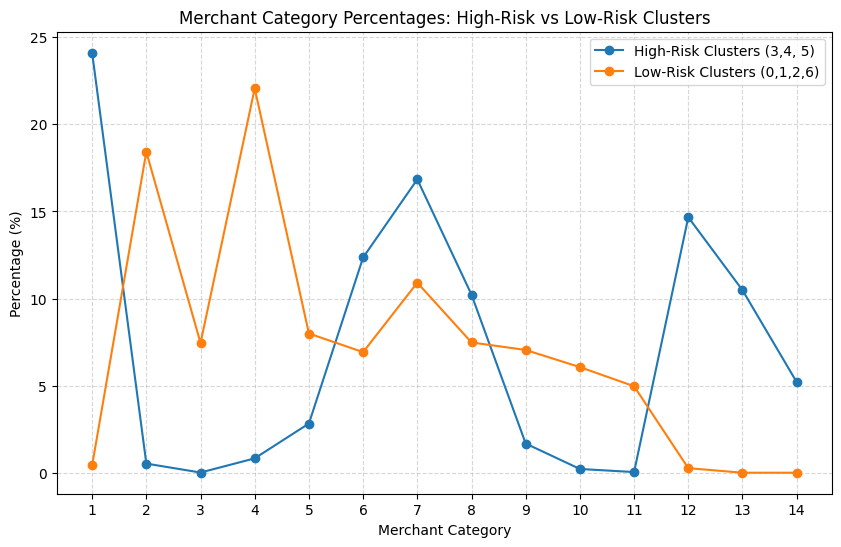

In [62]:
#Plot high risk vs low risk clusters using Merchant Categories, expressed as percentage
plt.figure(figsize=(10, 6))

plt.plot(
    pct_df.index,
    pct_df["high_risk_pct"],
    marker="o",
    label="High-Risk Clusters (3,4, 5)"
)

plt.plot(
    pct_df.index,
    pct_df["low_risk_pct"],
    marker="o",
    label="Low-Risk Clusters (0,1,2,6)"
)

plt.title("Merchant Category Percentages: High-Risk vs Low-Risk Clusters")
plt.xlabel("Merchant Category")
plt.ylabel("Percentage (%)")
plt.xticks(pct_df.index)  # show all categories
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.show()


1=Travel, 2=online_retail, 3=pharmacy, 4=grocery, 5=clothing, 6=atm, 7=restaurant, 8=gas_station, 9=electronics, 10=hotel, 11= utilities, 12=money_transfer, 13=crypto, 14=gambling

In [63]:
df[df["cluster"].isin([3, 4, 5])].groupby("cluster")["is_foreign_txn"].value_counts(normalize=True) * 100

cluster  is_foreign_txn
3        0                 70.015331
         1                 29.984669
4        0                 69.988245
         1                 30.011755
5        1                 58.359235
         0                 41.640765
Name: proportion, dtype: float64

In [64]:
df[df["cluster"].isin([0, 1, 2, 6])].groupby("cluster")["is_foreign_txn"].value_counts(normalize=True) * 100

cluster  is_foreign_txn
0        0                 71.771031
         1                 28.228969
1        0                 71.719356
         1                 28.280644
2        0                 80.551014
         1                 19.448986
6        0                 70.582652
         1                 29.417348
Name: proportion, dtype: float64

In [65]:
high_risk = df[df["cluster"].isin([3, 4, 5])]
low_risk = df[df["cluster"].isin([0, 1, 2, 6])]

# Percentage distribution for each group
high_pct = (
    high_risk["is_foreign_txn"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("high_risk_pct")
)

low_pct = (
    low_risk["is_foreign_txn"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("low_risk_pct")
)

# Combine into one DataFrame
pct_df = pd.concat([high_pct, low_pct], axis=1).fillna(0).sort_index()
pct_df


,high_risk_pct,low_risk_pct
is_foreign_txn,,
0,57.362393,73.665652
1,42.637607,26.334348


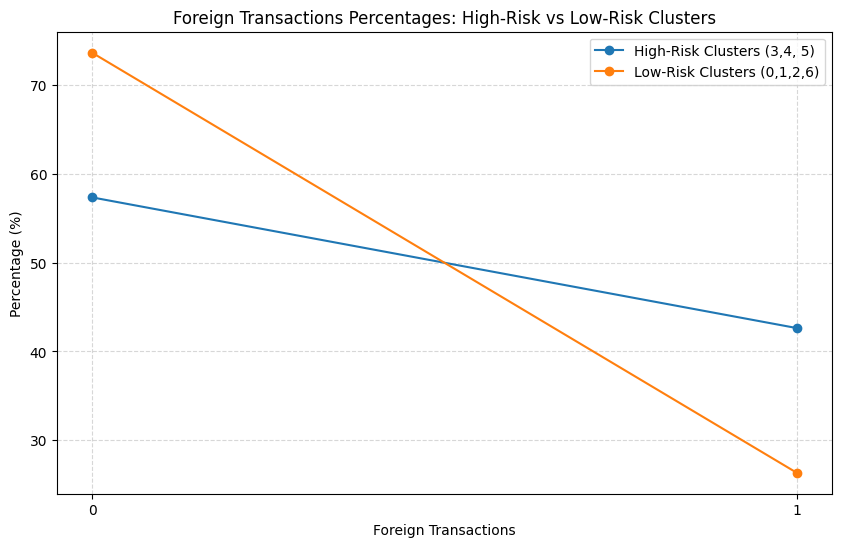

In [66]:
#Plot high risk vs low risk clusters using is_foreign_txn, expressed as percentage
plt.figure(figsize=(10, 6))

plt.plot(
    pct_df.index,
    pct_df["high_risk_pct"],
    marker="o",
    label="High-Risk Clusters (3,4, 5)"
)

plt.plot(
    pct_df.index,
    pct_df["low_risk_pct"],
    marker="o",
    label="Low-Risk Clusters (0,1,2,6)"
)

plt.title("Foreign Transactions Percentages: High-Risk vs Low-Risk Clusters")
plt.xlabel("Foreign Transactions")
plt.ylabel("Percentage (%)")
plt.xticks(pct_df.index)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.show()


Anecdote below:

In [67]:
#percent of transaction where card is not present
df.groupby("cluster")["card_present"].apply(lambda x: (x == 0).mean() * 100)





,card_present
cluster,
0,64.887281
1,64.951928
2,64.879084
3,65.024274
4,65.097024
5,65.396298
6,64.752377


In [68]:
#previously calculated percentage difference between high and low risk clusters at 0.34%
#calculate avg for all clusters
abs(1-(df.groupby("cluster")["card_present"].apply(lambda x: (x == 0).mean() * 100)).mean())


np.float64(63.99832375621703)

In [69]:
#percent of transactions that are processed without a card present
(abs(1-(df.groupby("cluster")["card_present"].apply(lambda x: (x == 0).mean() * 100)).mean()) /100) *1000000



np.float64(639983.2375621704)

In [70]:
#number of transaction processed without a card present are in a high risk cluster
639983 *.0034

2175.9422

In [71]:
#number of transaction processed without a card present are in a high risk cluster, appx 1% will be fraud based on 5% fraud rate in high risk clusters
2175 *.05

108.75

In [72]:
108.75/1000000 #percent of card not present transactions predicted to be fraud
(108.75/1000000) * 165000000 #multiply by number of purchases daily in 2025

17943.75

Small changes equal big dollars. Even though the card not present category detected on a small 0.34% change, in a dataset with a million transactions that equals 108 transactions that are predicted to be fraud or .01% of fraud, but multiply that by the 165,000,000 transactions processed a day in 2025 and it becomes 17,944 fraud transactions a day or 6,500,000 million per year. Since we know fraud tends to have a higher dollar amount with the above 50th percentile ranging between $69.08 and $479.76 in the high risk clusters, we can roughly estimate a loss between $1,239,571 and $8,608,813 per day (17,944 * $69.08 or $479.76).